In [ ]:
#%load_ext autoreload
#%autoreload 2

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import FASHION_MNIST_NAMES, SYNTH_NAMES
from experiments import KMeansExperiment
#plot params
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LIST_SEED = [42, 123, 456, 789, 101112]
MAX_ITER = 100
K = 10
store = KMeansExperiment()

# K-Means Clustering: Final Evaluation

This notebook evaluates a custom K-Means implementation across two datasets: **Fashion MNIST** and a **Synthetic dataset**. We analyze convergence, cluster assignments, inertia, and overall accuracy across multiple random seeds to test the stability of the algorithm.

## Fashion MNIST dataset

### K-means

In [47]:
for seed in LIST_SEED:
    store.run_experiment(
        method="kmeans_simple",
        dataset_type="fashion_mnist",
        k=10,
        max_iter=100,
        seed=seed,
    )
    res = store.results["kmeans_simple"]["fashion_mnist"][seed]
    print(f"Seed {seed:6} | Acc: {res['accuracy']:.3f} | Inertia: {res['inertia']:.1f}")

Converged after 29 iterations.
Seed     42 | Acc: 0.483 | Inertia: 31788.1
Converged after 11 iterations.
Seed    123 | Acc: 0.523 | Inertia: 31154.7
Converged after 31 iterations.
Seed    456 | Acc: 0.522 | Inertia: 31800.2
Converged after 22 iterations.
Seed    789 | Acc: 0.572 | Inertia: 29122.5
Converged after 11 iterations.
Seed 101112 | Acc: 0.536 | Inertia: 31903.7


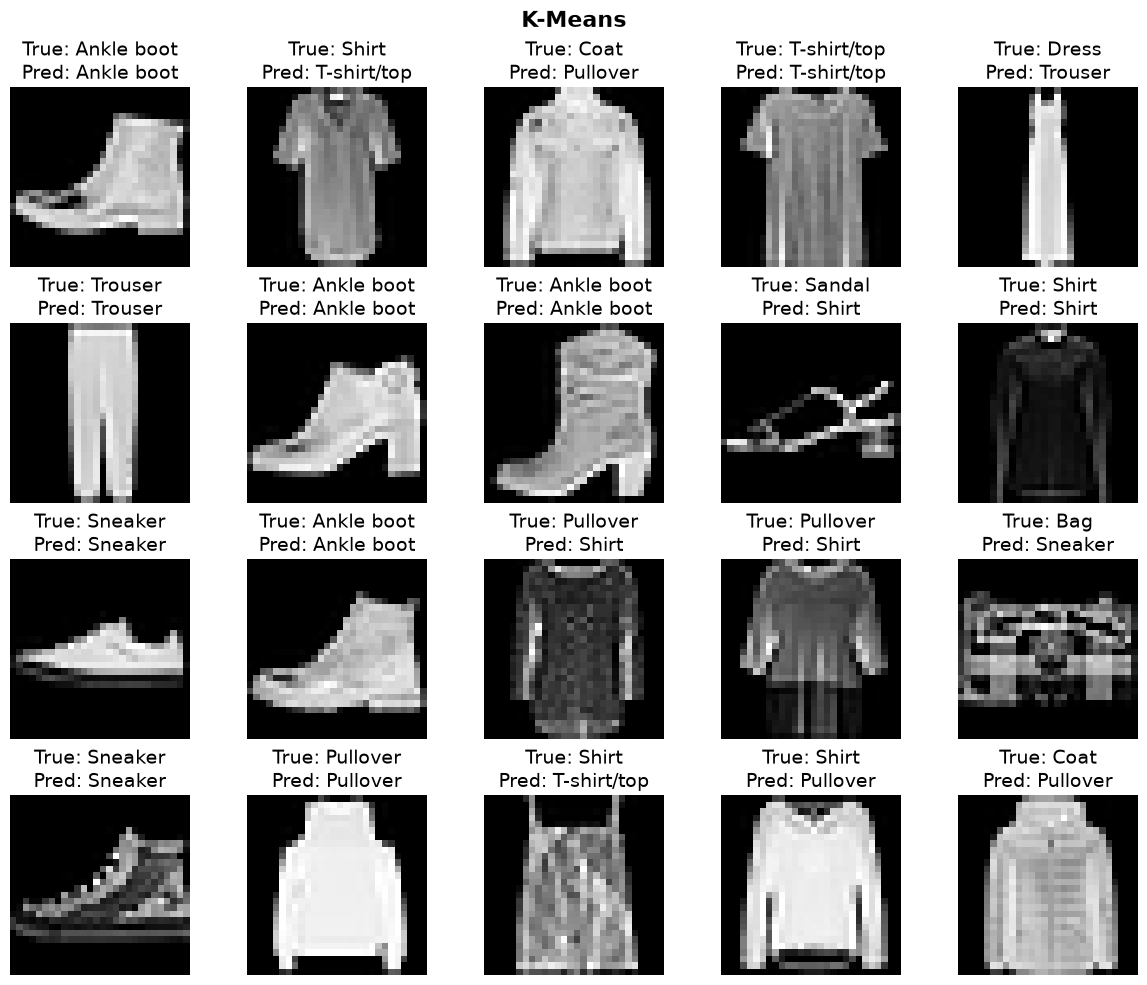

In [48]:
seed = 42
res = store.results["kmeans_simple"]["fashion_mnist"][seed]
X_original = res["x_original"]
y_true = res["y_label_name"]
y_pred = res["y_new_label_name"]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_original[i], cmap="gray")

    ax.set_title(
        f"True: {y_true[i]}\n"
        f"Pred: {y_pred[i]}"
    )
    fig.suptitle("K-Means", fontsize=16, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

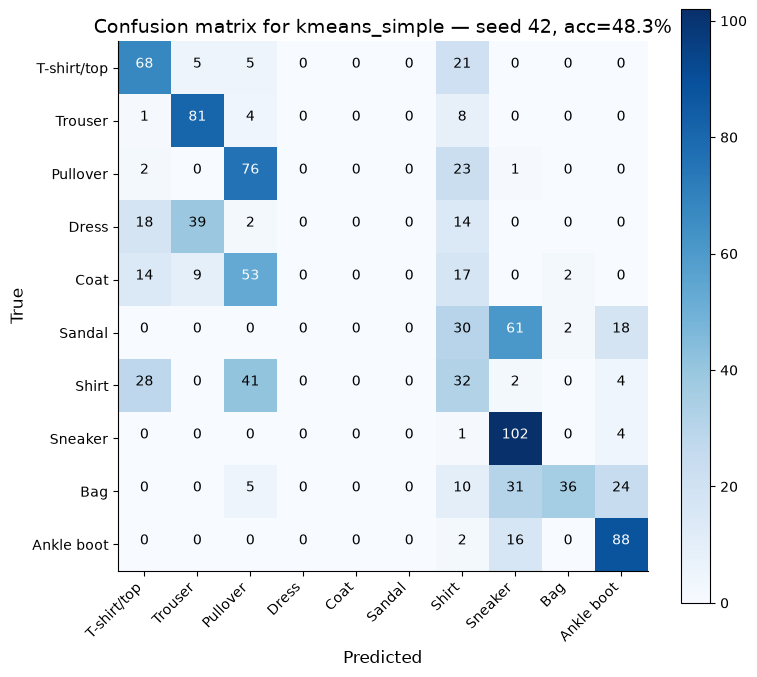

In [49]:
#Coinfusion matrix
seed = 42
method = "kmeans_simple"
res = store.results["kmeans_simple"]["fashion_mnist"][seed]
y_true = res["y"]         # true int labels
y_pred = res["y_mapped"]  # mapped predicted labels
names  = [FASHION_MNIST_NAMES[i] for i in range(10)]

labels = np.arange(10)
cm = pd.crosstab(pd.Series(y_true, name="True"),
                 pd.Series(y_pred, name="Pred")).reindex(
                 index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(labels); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(labels); ax.set_yticklabels(names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in labels:
    for j in labels:
        v = cm.values[i, j]
        ax.text(j, i, v, ha="center",
                color="white" if v > cm.values.max()/2 else "black")
ax.set_title(f"Confusion matrix for {method} — seed {seed}, acc={res['accuracy']:.1%}")
plt.colorbar(im); plt.tight_layout(); plt.show()


### K-means++

In [50]:
for seed in LIST_SEED:
    store.run_experiment(
        method="kmeans_plusplus",
        dataset_type="fashion_mnist",
        k=10,
        max_iter=100,
        seed=seed,
    )
    res = store.results["kmeans_plusplus"]["fashion_mnist"][seed]
    print(f"Seed {seed:6} | Acc: {res['accuracy']:.3f} | Inertia: {res['inertia']:.1f}")

Converged after 18 iterations.
Seed     42 | Acc: 0.532 | Inertia: 32826.7
Converged after 13 iterations.
Seed    123 | Acc: 0.528 | Inertia: 31831.1
Converged after 15 iterations.
Seed    456 | Acc: 0.503 | Inertia: 31673.3
Converged after 21 iterations.
Seed    789 | Acc: 0.512 | Inertia: 29321.7
Converged after 24 iterations.
Seed 101112 | Acc: 0.520 | Inertia: 31723.9


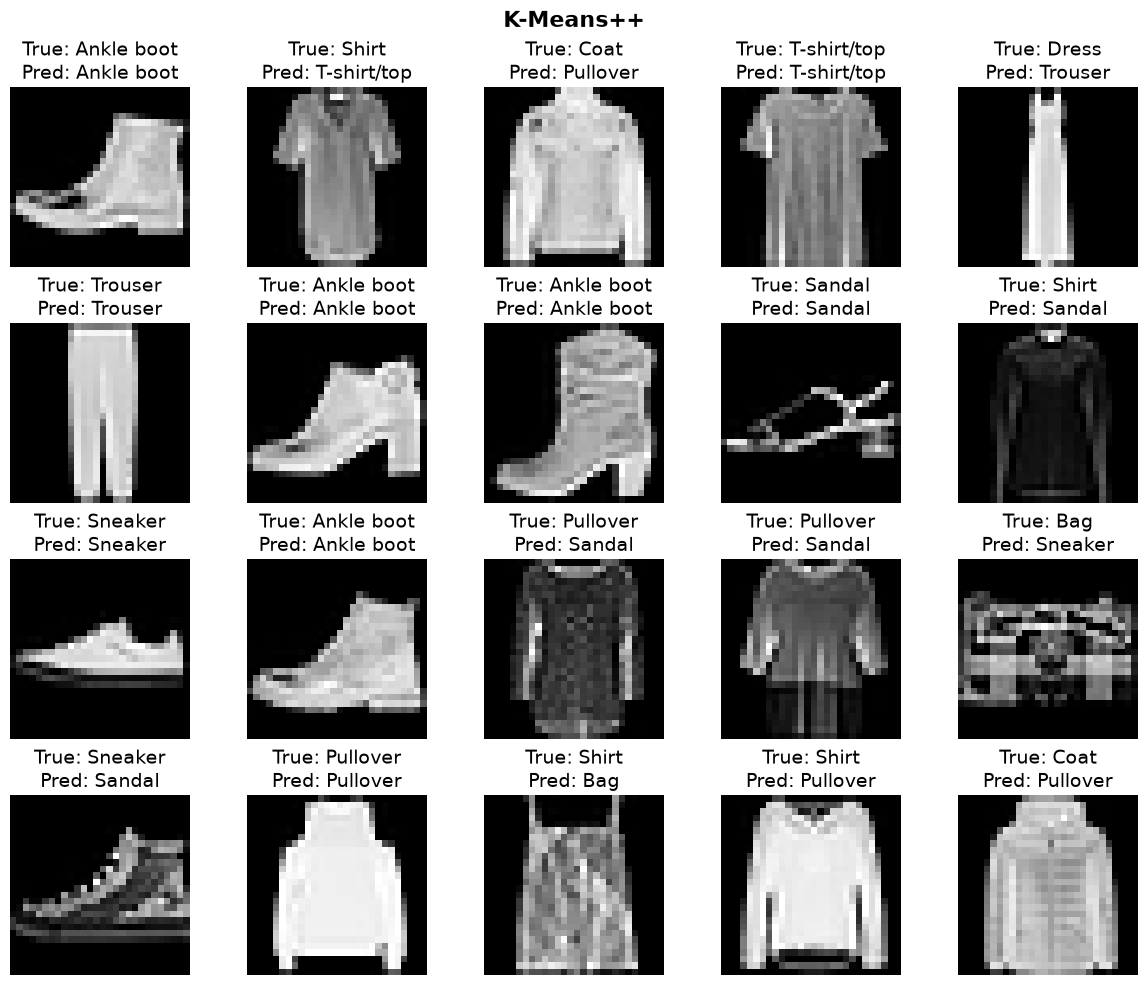

In [51]:
seed = 42
res = store.results["kmeans_plusplus"]["fashion_mnist"][seed]
X_original = res["x_original"]
y_true = res["y_label_name"]
y_pred = res["y_new_label_name"]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_original[i], cmap="gray")

    ax.set_title(
        f"True: {y_true[i]}\n"
        f"Pred: {y_pred[i]}"
    )
    fig.suptitle("K-Means++", fontsize=16, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

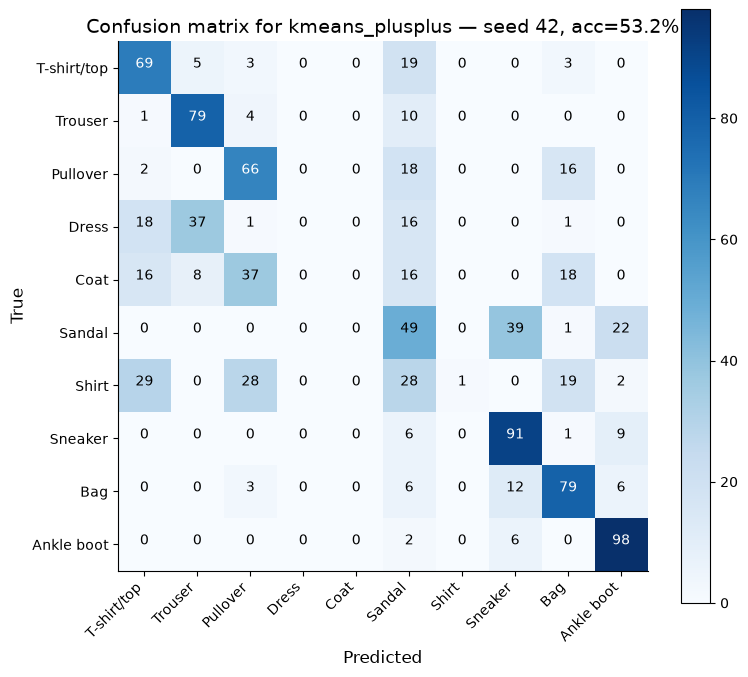

In [52]:
#Confusion matrix
seed = 42
method = "kmeans_plusplus"
res = store.results["kmeans_plusplus"]["fashion_mnist"][seed]
y_true = res["y"]         # true int labels
y_pred = res["y_mapped"]  # mapped predicted labels
names  = [FASHION_MNIST_NAMES[i] for i in range(10)]

labels = np.arange(10)
cm = pd.crosstab(pd.Series(y_true, name="True"),
                 pd.Series(y_pred, name="Pred")).reindex(
                 index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(labels); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(labels); ax.set_yticklabels(names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in labels:
    for j in labels:
        v = cm.values[i, j]
        ax.text(j, i, v, ha="center",
                color="white" if v > cm.values.max()/2 else "black")
ax.set_title(f"Confusion matrix for {method} — seed {seed}, acc={res['accuracy']:.1%}")
plt.colorbar(im); plt.tight_layout(); plt.show()


### Inertia nad Variability

It measures the ssum of sqaured distance between dat points (x_i) and their assigned cluster centroids

$$\text{inertia} = \sum_{i=1}^{n} \lVert x_i - \mu_{c(i)} \rVert^2$$

In [54]:
inertia_simple = [store.results["kmeans_simple"]["fashion_mnist"][s]["inertia"] for s in LIST_SEED]
inertia_plus = [store.results["kmeans_plusplus"]["fashion_mnist"][s]["inertia"] for s in LIST_SEED]
print("Inertia (Simple):", [f"{v:.1f}" for v in inertia_simple])
print("Inertia (K-Means++):", [f"{v:.1f}" for v in inertia_plus])

Inertia (Simple): ['31788.1', '31154.7', '31800.2', '29122.5', '31903.7']
Inertia (K-Means++): ['32826.7', '31831.1', '31673.3', '29321.7', '31723.9']


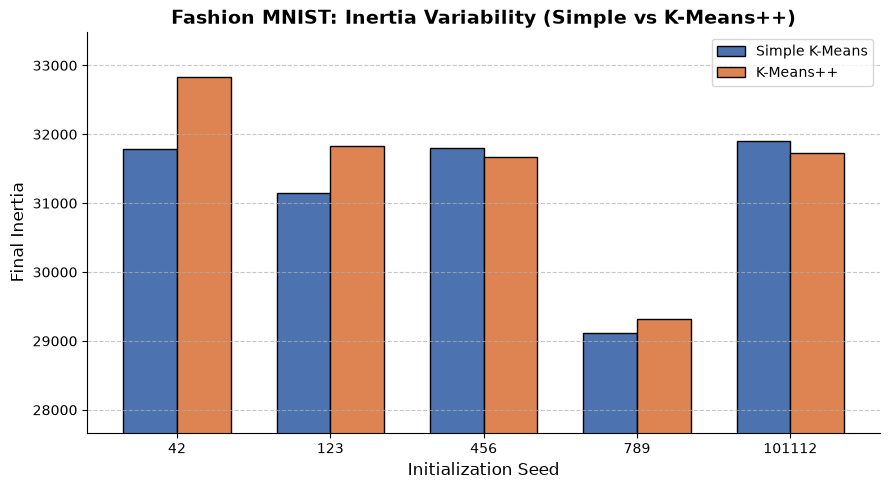

In [55]:
x = np.arange(len(LIST_SEED))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, inertia_simple, width, label='Simple K-Means', color='#4C72B0', edgecolor="black")
ax.bar(x + width/2, inertia_plus, width, label='K-Means++', color='#DD8452', edgecolor="black")

ax.set_xticks(x); ax.set_xticklabels([str(s) for s in LIST_SEED])
ax.set_ylabel("Final Inertia"); ax.set_xlabel("Initialization Seed")
ax.set_title("Fashion MNIST: Inertia Variability (Simple vs K-Means++)", fontweight="bold")
ax.legend(loc="best")
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Zoom in on the Y-axis to make the differences obvious
min_val = min(min(inertia_simple), min(inertia_plus))
max_val = max(max(inertia_simple), max(inertia_plus))
ax.set_ylim(min_val * 0.95, max_val * 1.02)

plt.tight_layout(); plt.show()

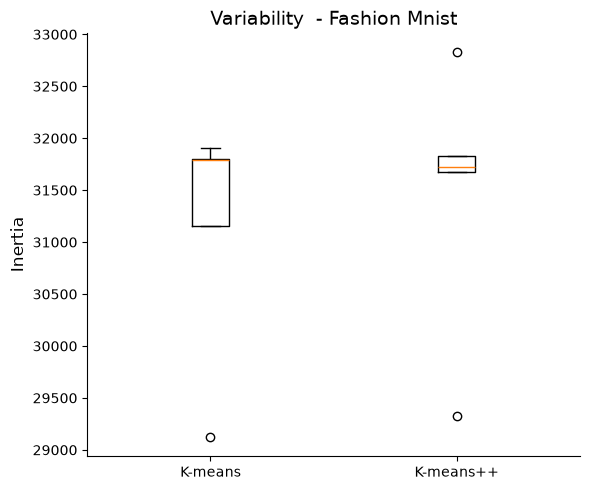

In [56]:
fig, ax = plt.subplots(figsize=(6, 5))

# Changed 'labels' to 'tick_labels'
ax.boxplot([inertia_simple, inertia_plus], tick_labels=["K-means", "K-means++"])

# Apply simple styling to match your reference
ax.set_ylabel("Inertia")
ax.set_title(f"Variability  - {dataset.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

## Synthetic dataset

### K-means

In [ ]:
for seed in LIST_SEED:
    store.run_experiment(
        method="kmeans_simple",
        dataset_type="synthetic",
        k=10,
        max_iter=100,
        seed=seed,
    )
    res = store.results["kmeans_simple"]["synthetic"][seed]
    print(f"Seed {seed:6} | Acc: {res['accuracy']:.3f} | Inertia: {res['inertia']:.1f}")

In [ ]:
#Coinfusion matrix
seed = 42
method = "kmeans_simple"
res = store.results["kmeans_simple"]["synthetic"][seed]
y_true = res["y"]         # true int labels
y_pred = res["y_mapped"]  # mapped predicted labels
names  = [SYNTH_NAMES[i] for i in range(10)]

labels = np.arange(10)
cm = pd.crosstab(pd.Series(y_true, name="True"),
                 pd.Series(y_pred, name="Pred")).reindex(
                 index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(labels); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(labels); ax.set_yticklabels(names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in labels:
    for j in labels:
        v = cm.values[i, j]
        ax.text(j, i, v, ha="center",
                color="white" if v > cm.values.max()/2 else "black")
ax.set_title(f"Confusion matrix for {method} — seed {seed}, acc={res['accuracy']:.1%}")
plt.colorbar(im); plt.tight_layout(); plt.show()

### K-means++

In [ ]:
for seed in LIST_SEED:
    store.run_experiment(
        method="kmeans_plusplus",
        dataset_type="synthetic",
        k=10,
        max_iter=100,
        seed=seed,
    )
    res = store.results["kmeans_plusplus"]["synthetic"][seed]
    print(f"Seed {seed:6} | Acc: {res['accuracy']:.3f} | Inertia: {res['inertia']:.1f}")

In [ ]:
#Confusion matrix
seed = 42
method = "kmeans_plusplus"
res = store.results["kmeans_plusplus"]["synthetic"][seed]
y_true = res["y"]         # true int labels
y_pred = res["y_mapped"]  # mapped predicted labels
names  = [SYNTH_NAMES[i] for i in range(10)]

labels = np.arange(10)
cm = pd.crosstab(pd.Series(y_true, name="True"),
                 pd.Series(y_pred, name="Pred")).reindex(
                 index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(labels); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(labels); ax.set_yticklabels(names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in labels:
    for j in labels:
        v = cm.values[i, j]
        ax.text(j, i, v, ha="center",
                color="white" if v > cm.values.max()/2 else "black")
ax.set_title(f"Confusion matrix for {method} — seed {seed}, acc={res['accuracy']:.1%}")
plt.colorbar(im); plt.tight_layout(); plt.show()


### Inertia and Variability

In [ ]:
inertia_simple = [store.results["kmeans_simple"]["synthetic"][s]["inertia"] for s in LIST_SEED]
inertia_plus = [store.results["kmeans_plusplus"]["synthetic"][s]["inertia"] for s in LIST_SEED]
print("Inertia (Simple):", [f"{v:.1f}" for v in inertia_simple])
print("Inertia (K-Means++):", [f"{v:.1f}" for v in inertia_plus])

In [ ]:
x = np.arange(len(LIST_SEED))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, inertia_simple, width, label='Simple K-Means', color='#4C72B0', edgecolor="black")
ax.bar(x + width/2, inertia_plus, width, label='K-Means++', color='#DD8452', edgecolor="black")

ax.set_xticks(x); ax.set_xticklabels([str(s) for s in LIST_SEED])
ax.set_ylabel("Final Inertia"); ax.set_xlabel("Initialization Seed")
ax.set_title("Synthetic: Inertia Variability (Simple vs K-Means++)", fontweight="bold")
ax.legend(loc="best")
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Zoom in on the Y-axis to make the differences obvious
min_val = min(min(inertia_simple), min(inertia_plus))
max_val = max(max(inertia_simple), max(inertia_plus))
ax.set_ylim(min_val * 0.95, max_val * 1.02)

plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# Changed 'labels' to 'tick_labels'
ax.boxplot([inertia_simple, inertia_plus], tick_labels=["K-means", "K-means++"])

# Apply simple styling to match your reference
ax.set_ylabel("Inertia")
ax.set_title(f"Variability  - {dataset.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

# Summary

In [ ]:
df = pd.DataFrame(store.summary)


stats = df.groupby(["dataset", "method"]).agg({
    "accuracy": ["mean", "std", "min", "max"],
    "inertia":  ["mean", "std", "min", "max"]
}).round(4).groupby(level=0).agg(lambda x: x if isinstance(x, str) else x.values.tolist())
print(stats)